In [ ]:

# TASK 1 Classification 
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = datasets.load_iris()
X = iris.data
y = iris.target
y = (y == 0).astype(int)  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred))

SVM Accuracy: 1.0


In [ ]:
# TASK 2 Linear Regression
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

df = pd.read_csv("house_prices.csv")
x = df[['bedrooms', 'bathrooms']].values  
y = df['price'].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

LR = LinearRegression()
ModelLR = LR.fit(x_train, y_train)
PredictionLR = ModelLR.predict(x_test)

print("Predictions:", PredictionLR)

print('LR Testing Accuracy')
teachLR = r2_score(y_test, PredictionLR)
testingAccLR = teachLR * 100
print(testingAccLR)

Predictions: [582069.24385941 778398.41126519 641393.04471498 ... 267092.4747425
 385740.07645364 582069.24385941]
LR Testing Accuracy
27.309464778014338


In [20]:

# TASK 2 Decision Tree Classifier
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = datasets.load_iris()
x = iris.data
y = iris.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

DT = DecisionTreeClassifier()
ModelDT = DT.fit(x_train, y_train)
PredictionDT = DT.predict(x_test)
print("Predictions:", PredictionDT)

print('DT Training Accuracy')
tracDT = DT.score(x_train, y_train) 
TrainingAccDT = tracDT * 100
print(f"Training Accuracy: {TrainingAccDT:.2f}%")

print('DT Testing Accuracy')
teacDT = accuracy_score(y_test, PredictionDT)
testingAccDT = teacDT * 100
print(f"Testing Accuracy: {testingAccDT:.2f}%")

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]
DT Training Accuracy
Training Accuracy: 100.00%
DT Testing Accuracy
Testing Accuracy: 100.00%


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


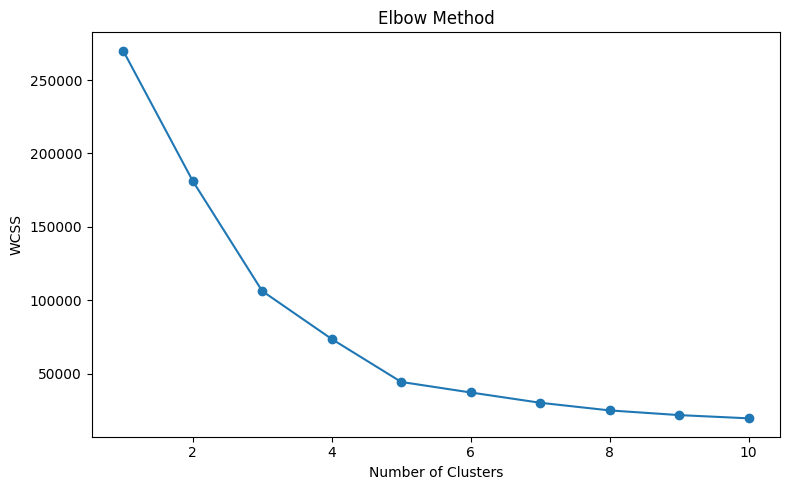

Elbow graph saved as elbow_curve.png


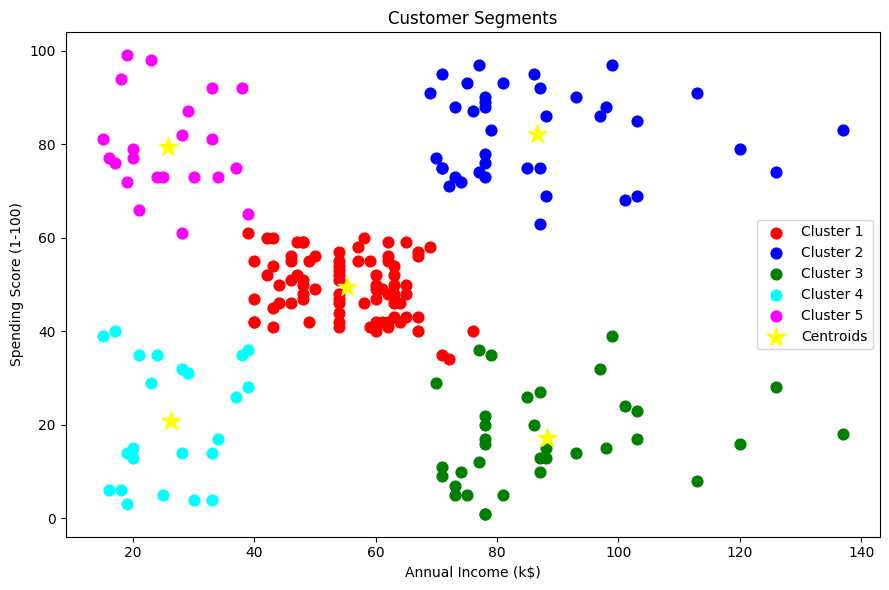

Cluster visualization saved as cluster_visualization.png
   CustomerID  Annual Income (k$)  Spending Score (1-100)  Cluster
0           1                  15                      39        3
1           2                  15                      81        4
2           3                  16                       6        3
3           4                  16                      77        4
4           5                  17                      40        3
5           6                  17                      76        4
6           7                  18                       6        3
7           8                  18                      94        4
8           9                  19                       3        3
9          10                  19                      72        4


In [21]:

# TASK 3  Customer Segmentation 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv("Mall_Customers.csv") 

print(df.head())
x = df.iloc[:, [3, 4]].values
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=0)
    km.fit(x)
    wcss.append(km.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.tight_layout()
plt.savefig('elbow_curve.png')
plt.show()
print("Elbow graph saved as elbow_curve.png")

kmeansmodel = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=0)
y_cluster = kmeansmodel.fit_predict(x)
plt.figure(figsize=(9, 6))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']
for i in range(5):
    plt.scatter(x[y_cluster == i, 0], x[y_cluster == i, 1],
                s=60, c=colors[i], label=labels[i])
plt.scatter(kmeansmodel.cluster_centers_[:, 0],
            kmeansmodel.cluster_centers_[:, 1],
            s=200, c='yellow', marker='*', label='Centroids')
plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.tight_layout()
plt.savefig('cluster_visualization.png')
plt.show()
print("Cluster visualization saved as cluster_visualization.png")
df['Cluster'] = y_cluster
print(df[['CustomerID', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].head(10))